# Model FR - UCI IHEPC Dataset (France)

**Author:** Nofal Rafif Setiawan
**NIM:** 221011402613
**Dataset:** UCI Individual Household Power Consumption (Sceaux, France)
**Algorithm:** Random Forest Regressor
**Target Performance:** R² > 0.82, MAE < 0.25 kW\n

---

## Dataset Characteristics

- **Total Records**: ~34,500 hourly measurements (derived from >2M minutely logs)
- **Date Range**: December 2006 - November 2010
- **Voltage**: 230-240V (European Standard)
- **Sub-metering**:
 - `Sub_metering_1`: Kitchen (Dishwasher, Oven, Microwave)
 - `Sub_metering_2`: Laundry Room (Washing Machine, Dryer, Fridge)
 - `Sub_metering_3`: Electric Water Heater & Air Conditioner
- **Context**: Benchmark dataset representing European energy consumption behaviors.
- **Pre-engineered Features**: Temporal (Hour, Day, Month), Lag_1, Lag_24, Lag_168

---

## Research Objectives

1. Validate Random Forest algorithm on a standard, high-quality dataset.
2. Serve as a performance benchmark for the Indonesian model.
3. Analyze feature importance in a stable energy grid environment.

## 1. Project Initialization
Importing necessary libraries and configuring visualization styles.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import os

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 2. Data Ingestion
Downloading the UCI Household Power Consumption dataset if not present.

In [2]:
def load_dataset(file_path='household_power_consumption.txt'):
    if not os.path.exists(file_path):
        !wget https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip -O household_power_consumption.zip
        !unzip -o household_power_consumption.zip

    # Dataset uses semicolon separator, missing values marked as '?'
    df = pd.read_csv(file_path, sep=';', na_values='?', low_memory=False)
    print(f"Data loaded. Shape: {df.shape}")
    return df

raw_df = load_dataset()

--2026-05-01 09:16:31--  https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘household_power_consumption.zip’

household_power_con     [   <=>              ]  19.68M  49.1MB/s    in 0.4s    

2026-05-01 09:16:31 (49.1 MB/s) - ‘household_power_consumption.zip’ saved [20640916]

Archive:  household_power_consumption.zip
  inflating: household_power_consumption.txt  
Data loaded. Shape: (2075259, 9)


## 3. Preprocessing & EDA
Cleaning the data, handling outliers, and resampling to hourly intervals to match the problem scope.

NaN setelah resample: 421 jam (1.22%)
Preprocessing complete. Shape: (34589, 7)


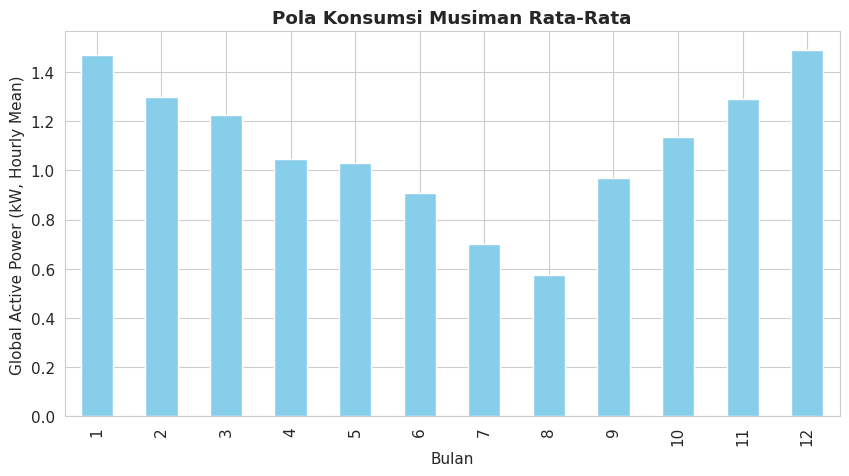

In [3]:
def preprocess_and_resample(df):
    df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
    df = df.set_index('Datetime').drop(['Date', 'Time'], axis=1)

    # Konversi numerik dulu agar string '?' menjadi NaN
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Resample langsung ke per jam TANPA ffill di level menit.
    # Jam dengan data parsial tetap dihitung mean-nya dari data yang ada.
    # Jam tanpa data sama sekali menjadi NaN.
    resample_rules = {
        'Global_active_power': 'mean',
        'Global_reactive_power': 'mean',
        'Voltage': 'mean',
        'Global_intensity': 'mean',
        'Sub_metering_1': 'sum',
        'Sub_metering_2': 'sum',
        'Sub_metering_3': 'sum'
    }
    df_h = df.resample('H').agg(resample_rules)

    nan_count = df_h['Global_active_power'].isna().sum()
    print(f"NaN setelah resample: {nan_count} jam ({nan_count/len(df_h)*100:.2f}%)")

    # Forward fill di level hourly, maks 24 jam berturut-turut.
    # Sisa NaN di luar limit akan hilang saat dropna() di feature engineering.
    df_h = df_h.ffill(limit=24)

    # IQR clipping dengan threshold 3x (konservatif)
    # agar variasi musiman yang valid tidak terpotong
    cols_to_clip = df_h.select_dtypes(include=[np.number]).columns
    for col in cols_to_clip:
        Q1 = df_h[col].quantile(0.25)
        Q3 = df_h[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 3 * IQR
        upper = Q3 + 3 * IQR
        df_h[col] = np.clip(df_h[col], lower, upper)

    print(f"Preprocessing complete. Shape: {df_h.shape}")
    return df_h

df_resampled = preprocess_and_resample(raw_df)

# Visualisasi pola konsumsi musiman
plt.figure(figsize=(10, 5))
monthly_pattern = df_resampled.groupby(df_resampled.index.month)['Global_active_power'].mean()
monthly_pattern.plot(kind='bar', color='skyblue')
plt.title('Pola Konsumsi Musiman Rata-Rata', fontweight='bold')
plt.xlabel('Bulan')
plt.ylabel('Global Active Power (kW, Hourly Mean)')
plt.show()

## 4. Feature Engineering
Creating signals for the model: Lag features (past behavior) and Temporal features (patterns).

In [4]:
def engineer_features(df):
    data = df.copy()

    # Temporal features
    # 'year' dihapus agar model tidak hafal tahun tertentu
    # 'day', 'month', 'is_weekend' dihapus karena permutation importance < 0.001
    data['hour'] = data.index.hour
    data['dayofweek'] = data.index.dayofweek

    # Lag features: menangkap pola masa lalu
    for lag in [1, 2, 3, 6, 12, 24, 168]:
        data[f'lag_{lag}'] = data['Global_active_power'].shift(lag)

    # Rate of change: arah perubahan konsumsi
    data['rate_of_change'] = data['lag_1'] - data['lag_2']

    # Rolling statistics: closed='left' memastikan window TIDAK menyertakan
    # nilai waktu-t (target). Untuk waktu t, rolling_mean_3 = mean(t-3, t-2, t-1).
    for window in [3, 24, 168]:
        data[f'rolling_mean_{window}'] = (
            data['Global_active_power']
            .rolling(window=window, closed='left')
            .mean()
        )
        data[f'rolling_std_{window}'] = (
            data['Global_active_power']
            .rolling(window=window, closed='left')
            .std()
        )

    rows_before = len(data)
    data = data.dropna()
    rows_dropped = rows_before - len(data)
    print(f"Feature engineering complete. Shape: {data.shape}")
    print(f"Rows dropped by dropna: {rows_dropped} ({rows_dropped/rows_before*100:.2f}%)")
    return data

df_final = engineer_features(df_resampled)

Feature engineering complete. Shape: (33151, 23)
Rows dropped by dropna: 1438 (4.16%)


## 5. Data Splitting
Using chronological split to respect time-series dependencies (no shuffling).

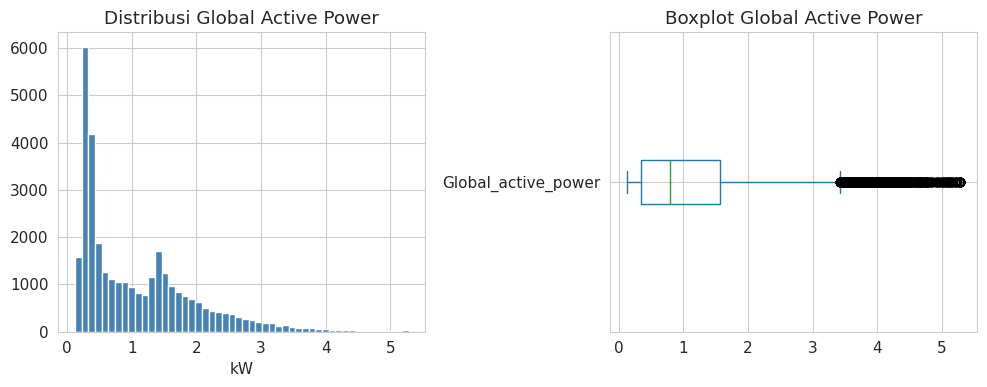

Target stats — Mean: 1.0875, Std: 0.8947, Min: 0.1240, Max: 5.2863

Training Samples: 26520
Testing Samples:  6631
Train period: 2006-12-23 to 2010-01-26
Test period:  2010-01-26 to 2010-11-26

Total features: 16
   1. hour
   2. dayofweek
   3. lag_1
   4. lag_2
   5. lag_3
   6. lag_6
   7. lag_12
   8. lag_24
   9. lag_168
  10. rate_of_change
  11. rolling_mean_3
  12. rolling_std_3
  13. rolling_mean_24
  14. rolling_std_24
  15. rolling_mean_168
  16. rolling_std_168


In [5]:
target = 'Global_active_power'

# Exclude fitur yang merepresentasikan data simultan (bukan prediktif)
excluded = ['Global_intensity', 'Voltage', 'Global_reactive_power',
            'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

features = [col for col in df_final.columns if col != target and col not in excluded]

X = df_final[features]
y = df_final[target]

# Distribusi target sebelum modeling
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
y.hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Distribusi Global Active Power')
plt.xlabel('kW')
plt.subplot(1, 2, 2)
y.plot(kind='box', vert=False)
plt.title('Boxplot Global Active Power')
plt.tight_layout()
plt.show()
print(f"Target stats — Mean: {y.mean():.4f}, Std: {y.std():.4f}, Min: {y.min():.4f}, Max: {y.max():.4f}")

# Chronological split
split_index = int(len(df_final) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"\nTraining Samples: {len(X_train)}")
print(f"Testing Samples:  {len(X_test)}")
print(f"Train period: {X_train.index[0].date()} to {X_train.index[-1].date()}")
print(f"Test period:  {X_test.index[0].date()} to {X_test.index[-1].date()}")
print(f"\nTotal features: {len(features)}")
for i, f in enumerate(features, 1):
    print(f"  {i:2d}. {f}")

## 6. Modeling
Training a **Random Forest Regressor** using `RandomizedSearchCV` for hyperparameter optimization.

In [6]:
def train_model(X_train, y_train):
    tscv = TimeSeriesSplit(n_splits=5)

    rf_param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 15, 20],
        'min_samples_split': [10, 20],
        'min_samples_leaf': [3, 5, 10],
        'max_features': ['sqrt', 'log2'],
    }

    rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

    # Scoring MAE agar konsisten dengan metrik evaluasi utama
    rf_grid = RandomizedSearchCV(
        estimator=rf_model,
        param_distributions=rf_param_grid,
        n_iter=30,
        cv=tscv,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    rf_grid.fit(X_train, y_train)

    print(f"Best MAE Score: {-rf_grid.best_score_:.4f}")
    print(f"Best Parameters: {rf_grid.best_params_}")

    return rf_grid.best_estimator_

rf_best = train_model(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best MAE Score: 0.3788
Best Parameters: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 15}


## 7. Evaluation
Analyzing model performance with metrics (MAE, RMSE, R²) and visualization (Actual vs Predicted, Residuals).

Naive Baseline (lag-1) — MAE: 0.3956 kW, R²: 0.3619

=== Model Performance ===
MAE  : 0.3286 kW
RMSE : 0.4779 kW
R²   : 0.6019

=== vs Naive Baseline ===
MAE improvement : 0.0670 kW (16.9% better)
R² improvement  : 0.2401


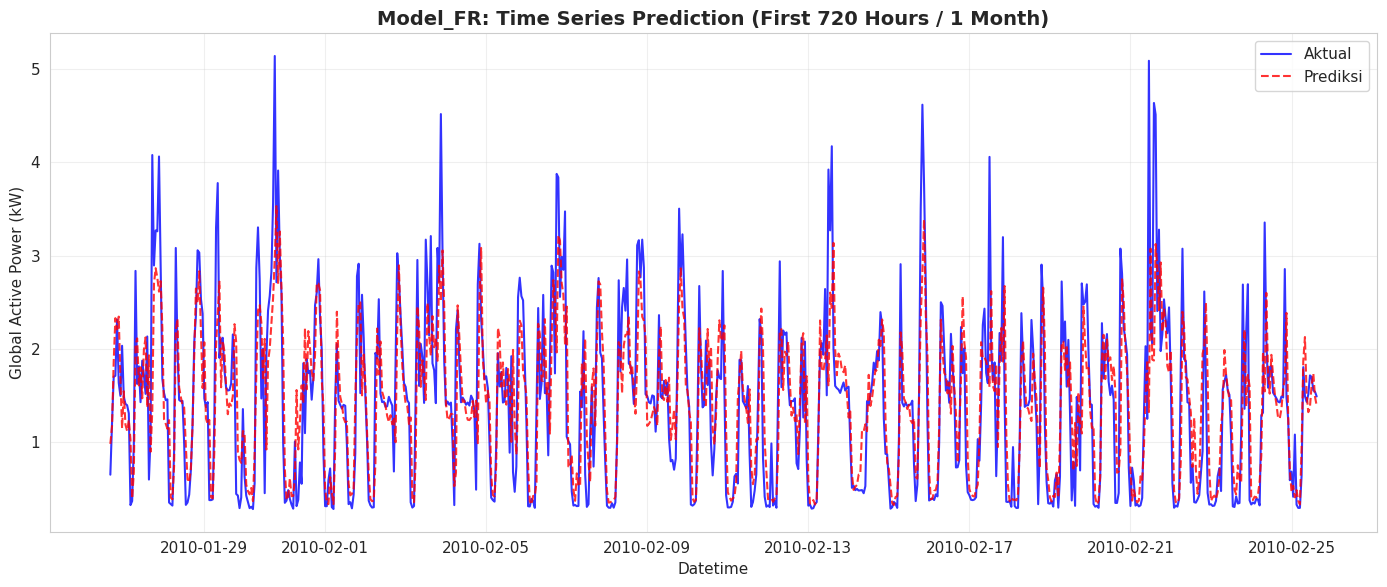

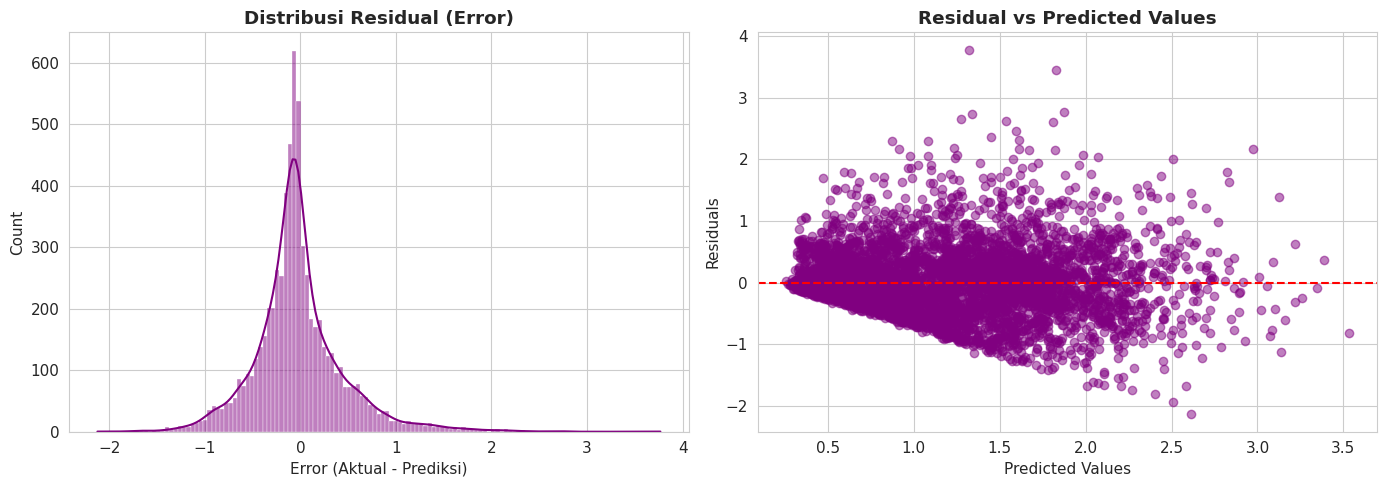

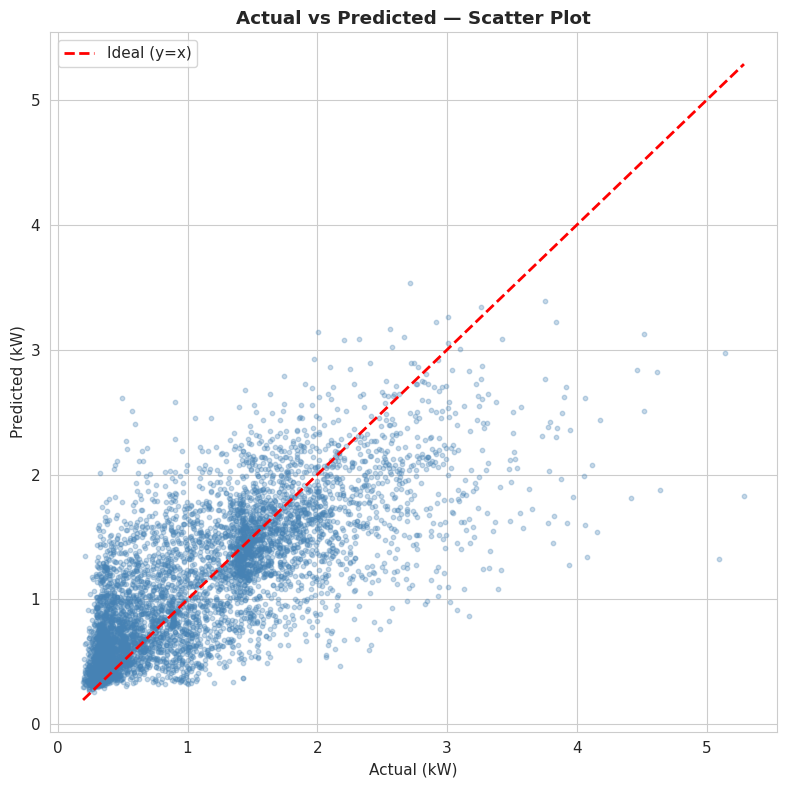

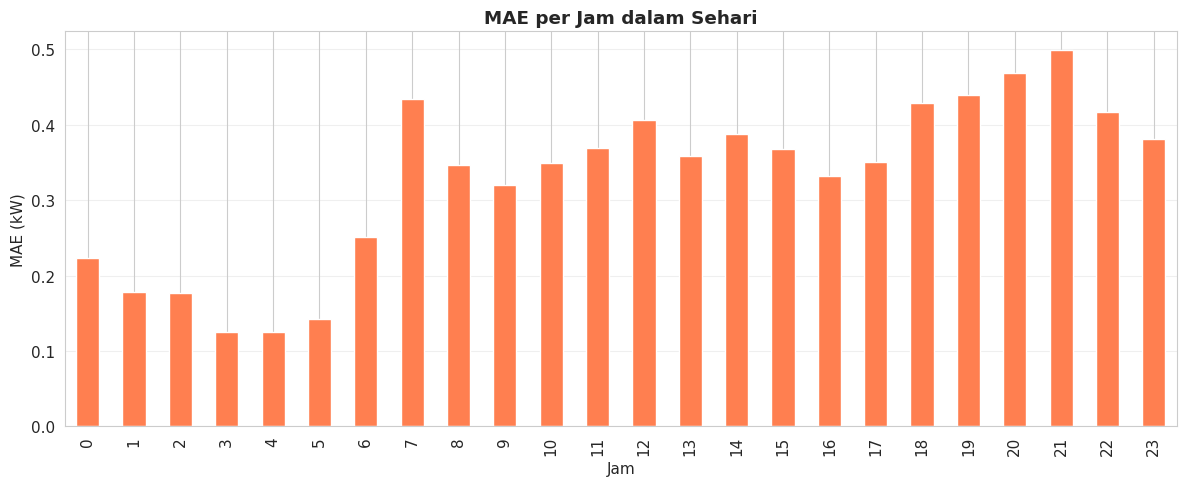

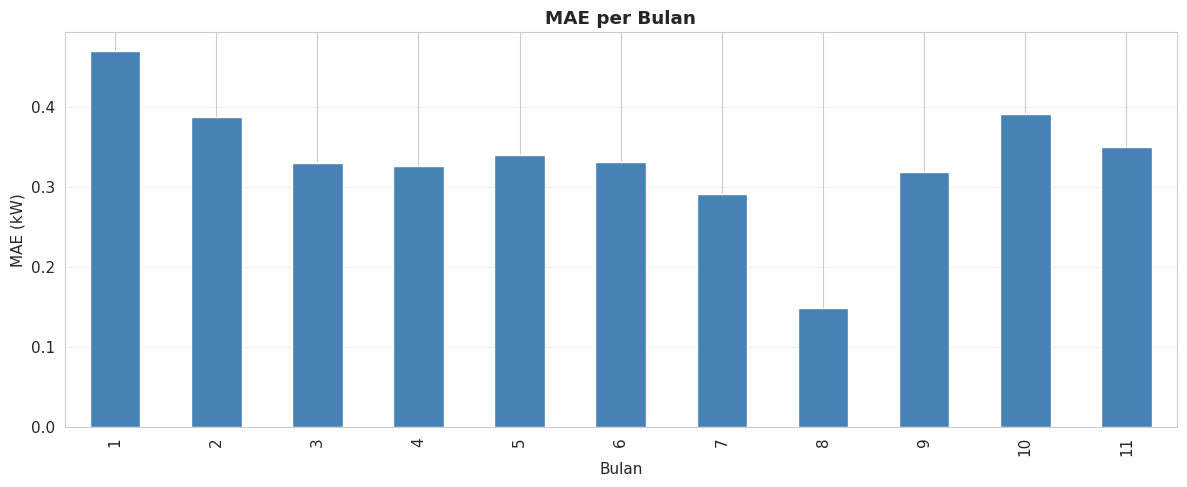

In [7]:
# Visualization Functions
def plot_actual_vs_predicted(y_test, y_pred, title):
    plt.figure(figsize=(14, 6))
    n_samples = 720  # 1 bulan data untuk representasi yang lebih baik

    plt.plot(y_test.index[:n_samples], y_test.values[:n_samples],
             label='Aktual', color='blue', linewidth=1.5, alpha=0.8)
    plt.plot(y_test.index[:n_samples], y_pred[:n_samples],
             label='Prediksi', color='red', linewidth=1.5, alpha=0.8, linestyle='--')

    plt.title(f'{title}: Time Series Prediction (First 720 Hours / 1 Month)', fontsize=14, fontweight='bold')
    plt.xlabel('Datetime')
    plt.ylabel('Global Active Power (kW)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_residuals(y_test, y_pred):
    residuals = y_test - y_pred
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(residuals, kde=True, color='purple')
    plt.title('Distribusi Residual (Error)', fontweight='bold')
    plt.xlabel('Error (Aktual - Prediksi)')

    plt.subplot(1, 2, 2)
    plt.scatter(y_pred, residuals, alpha=0.5, color='purple')
    plt.axhline(0, color='red', linestyle='--')
    plt.title('Residual vs Predicted Values', fontweight='bold')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.tight_layout()
    plt.show()

# === Naive Baseline ===
# Menggunakan lag_1 dari X_test sebagai prediksi naive,
# agar perbandingan fair: model juga melihat lag_1 sebagai input
y_naive_pred = X_test['lag_1']
mae_naive = mean_absolute_error(y_test, y_naive_pred)
r2_naive = r2_score(y_test, y_naive_pred)
print(f"Naive Baseline (lag-1) — MAE: {mae_naive:.4f} kW, R²: {r2_naive:.4f}")
print()

# === Model Evaluation ===
y_test_pred = rf_best.predict(X_test)

mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)

print(f"=== Model Performance ===")
print(f"MAE  : {mae:.4f} kW")
print(f"RMSE : {rmse:.4f} kW")
print(f"R²   : {r2:.4f}")
print()
print(f"=== vs Naive Baseline ===")
print(f"MAE improvement : {mae_naive - mae:.4f} kW ({(1 - mae/mae_naive)*100:.1f}% better)")
print(f"R² improvement  : {r2 - r2_naive:.4f}")

# Visualizations
plot_actual_vs_predicted(y_test, y_test_pred, 'Model_FR')
plot_residuals(y_test, y_test_pred)

# === Scatter Plot: Actual vs Predicted ===
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_test_pred, alpha=0.3, s=10, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Ideal (y=x)')
plt.xlabel('Actual (kW)')
plt.ylabel('Predicted (kW)')
plt.title('Actual vs Predicted — Scatter Plot', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# === Error Analysis per Jam dan per Bulan ===
test_df = pd.DataFrame({'actual': y_test, 'pred': y_test_pred})
test_df['abs_error'] = (test_df['actual'] - test_df['pred']).abs()
test_df['hour'] = test_df.index.hour
test_df['month'] = test_df.index.month

# MAE per jam
hourly_mae = test_df.groupby('hour')['abs_error'].mean()
plt.figure(figsize=(12, 5))
hourly_mae.plot(kind='bar', color='coral')
plt.title('MAE per Jam dalam Sehari', fontweight='bold')
plt.xlabel('Jam')
plt.ylabel('MAE (kW)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# MAE per bulan
monthly_mae = test_df.groupby('month')['abs_error'].mean()
plt.figure(figsize=(12, 5))
monthly_mae.plot(kind='bar', color='steelblue')
plt.title('MAE per Bulan', fontweight='bold')
plt.xlabel('Bulan')
plt.ylabel('MAE (kW)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 8. Model Interpretation (Feature Importance)
Identifying which features drive energy consumption. This section provides the scientific basis for the recommendation logic in the Web Application.

Extracting Feature Importance...


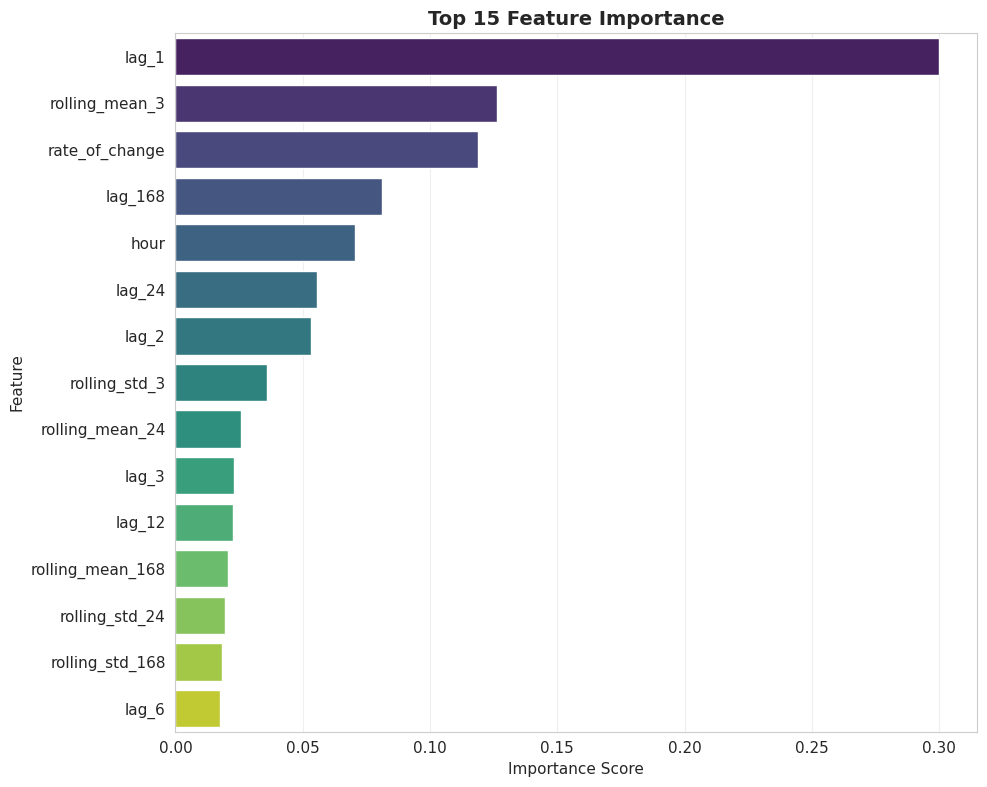


Top 5 Drivers:
          Feature  Importance
0           lag_1    0.299835
1  rolling_mean_3    0.126497
2  rate_of_change    0.118814
3         lag_168    0.081305
4            hour    0.070340


In [8]:
def plot_feature_importance_enhanced(model, feature_names):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    fi_df = pd.DataFrame({
        'Feature': [feature_names[i] for i in indices],
        'Importance': importances[indices]
    })

    plt.figure(figsize=(10, 8))
    top_n = min(15, len(fi_df))
    sns.barplot(x='Importance', y='Feature', data=fi_df.head(top_n), palette='viridis')
    plt.title(f'Top {top_n} Feature Importance', fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    return fi_df

print("Extracting Feature Importance...")
fi_df = plot_feature_importance_enhanced(rf_best, X.columns)
print("\nTop 5 Drivers:")
print(fi_df.head(5))

## 8b. Permutation Importance (Validation)
Feature importance bawaan Random Forest cenderung bias terhadap fitur dengan kardinalitas tinggi. Permutation importance mengukur dampak sebenarnya dari setiap fitur terhadap performa model dengan cara mengacak nilainya satu per satu, sehingga hasilnya lebih dapat dipertanggungjawabkan.

In [ ]:
perm_result = permutation_importance(
    rf_best, X_test, y_test,
    n_repeats=10,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

perm_sorted_idx = perm_result.importances_mean.argsort()[::-1]

plt.figure(figsize=(12, 6))
plt.bar(
    range(len(perm_sorted_idx)),
    perm_result.importances_mean[perm_sorted_idx],
    yerr=perm_result.importances_std[perm_sorted_idx],
    capsize=3, color='steelblue', ecolor='black'
)
plt.xticks(range(len(perm_sorted_idx)),
           [X_test.columns[i] for i in perm_sorted_idx],
           rotation=45, ha='right')
plt.title('Permutation Importance (Test Set)', fontweight='bold')
plt.ylabel('Mean Decrease in R²')
plt.tight_layout()
plt.show()

print('\nPerbandingan Feature Importance vs Permutation Importance:')
print(f"{'Feature':<25} {'RF Importance':>15} {'Perm Importance':>18}")
print('-' * 60)
for i in perm_sorted_idx:
    fname = X_test.columns[i]
    rf_imp = rf_best.feature_importances_[i]
    perm_imp = perm_result.importances_mean[i]
    print(f"{fname:<25} {rf_imp:>15.4f} {perm_imp:>18.4f}")

## 9. Model Serialization
Saving the trained model using `joblib` for deployment in the Web Application.

In [ ]:
model_filename = 'model_fr.joblib'

print(f"Saving model and metadata to {model_filename}...")

model_data = {
    'model': rf_best,
    'features': X.columns.tolist(),
    'lag_windows': [1, 2, 3, 6, 12, 24, 168],
    'rolling_windows': [3, 24, 168],
    'target': target,
    'train_end_date': str(X_train.index[-1]),
    'test_start_date': str(X_test.index[0])
}

joblib.dump(model_data, model_filename, compress=3)

file_size = os.path.getsize(model_filename) / (1024 * 1024)
print(f"Model saved. Size: {file_size:.2f} MB")
print(f"Features saved: {len(model_data['features'])} items")
print(f"Metadata keys: {list(model_data.keys())}")

# Verifikasi load-back
loaded = joblib.load(model_filename)
y_verify = loaded['model'].predict(X_test[:5])
y_original = rf_best.predict(X_test[:5])
if np.allclose(y_verify, y_original):
    print(f"\nLoad verification: OK")
else:
    diff = np.abs(y_verify - y_original).max()
    print(f"\nWARNING: Max prediction difference after load = {diff:.6f}")